---
## How to approach the project
1. Load data on global interest in workouts
2. Find the time of peak searches for workout
3. Find the most popular keywords for the current year and during covid
4. Find the country with the highest interest for workouts
5. Find the country in the MESA region with the highest interest in home workouts
---

In [34]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load data on global interest in workouts
Load workout.csv, which tracks global interest in the keyword "workout," from the 'data/' folder, and store in a DataFrame.


In [35]:
# Load datasets
workout = pd.read_csv("data/workout.csv", parse_dates=["month"])
three_keywords = pd.read_csv("data/three_keywords.csv", parse_dates=["month"])
workout_geo = pd.read_csv("data/workout_geo.csv")
three_keywords_geo = pd.read_csv("data/three_keywords_geo.csv")


In [36]:
workout.head()

,month,workout_worldwide
0,2018-03-01,59
1,2018-04-01,61
2,2018-05-01,57
3,2018-06-01,56
4,2018-07-01,51


In [37]:
three_keywords.head()

,month,home_workout_worldwide,gym_workout_worldwide,home_gym_worldwide
0,2018-03-01,12,16,10
1,2018-04-01,12,18,10
2,2018-05-01,13,16,9
3,2018-06-01,12,17,9
4,2018-07-01,12,17,9


In [38]:
workout_geo.head()

,country,workout_2018_2023
0,Guam,NaN
1,Falkland Islands (Islas Malvinas),NaN
2,Cook Islands,NaN
3,Brunei,NaN
4,Palau,NaN


In [39]:
three_keywords_geo.head()

,Country,home_workout_2018_2023,gym_workout_2018_2023,home_gym_2018_2023
0,Gibraltar,NaN,NaN,NaN
1,Lesotho,NaN,NaN,NaN
2,Guam,NaN,NaN,NaN
3,Botswana,NaN,NaN,NaN
4,Brunei,NaN,NaN,NaN


## 2. Find the time of peak searches for workout
You can use visualisation to identify the highest value for 'workout' searches.
- Identifying trends in workout interest

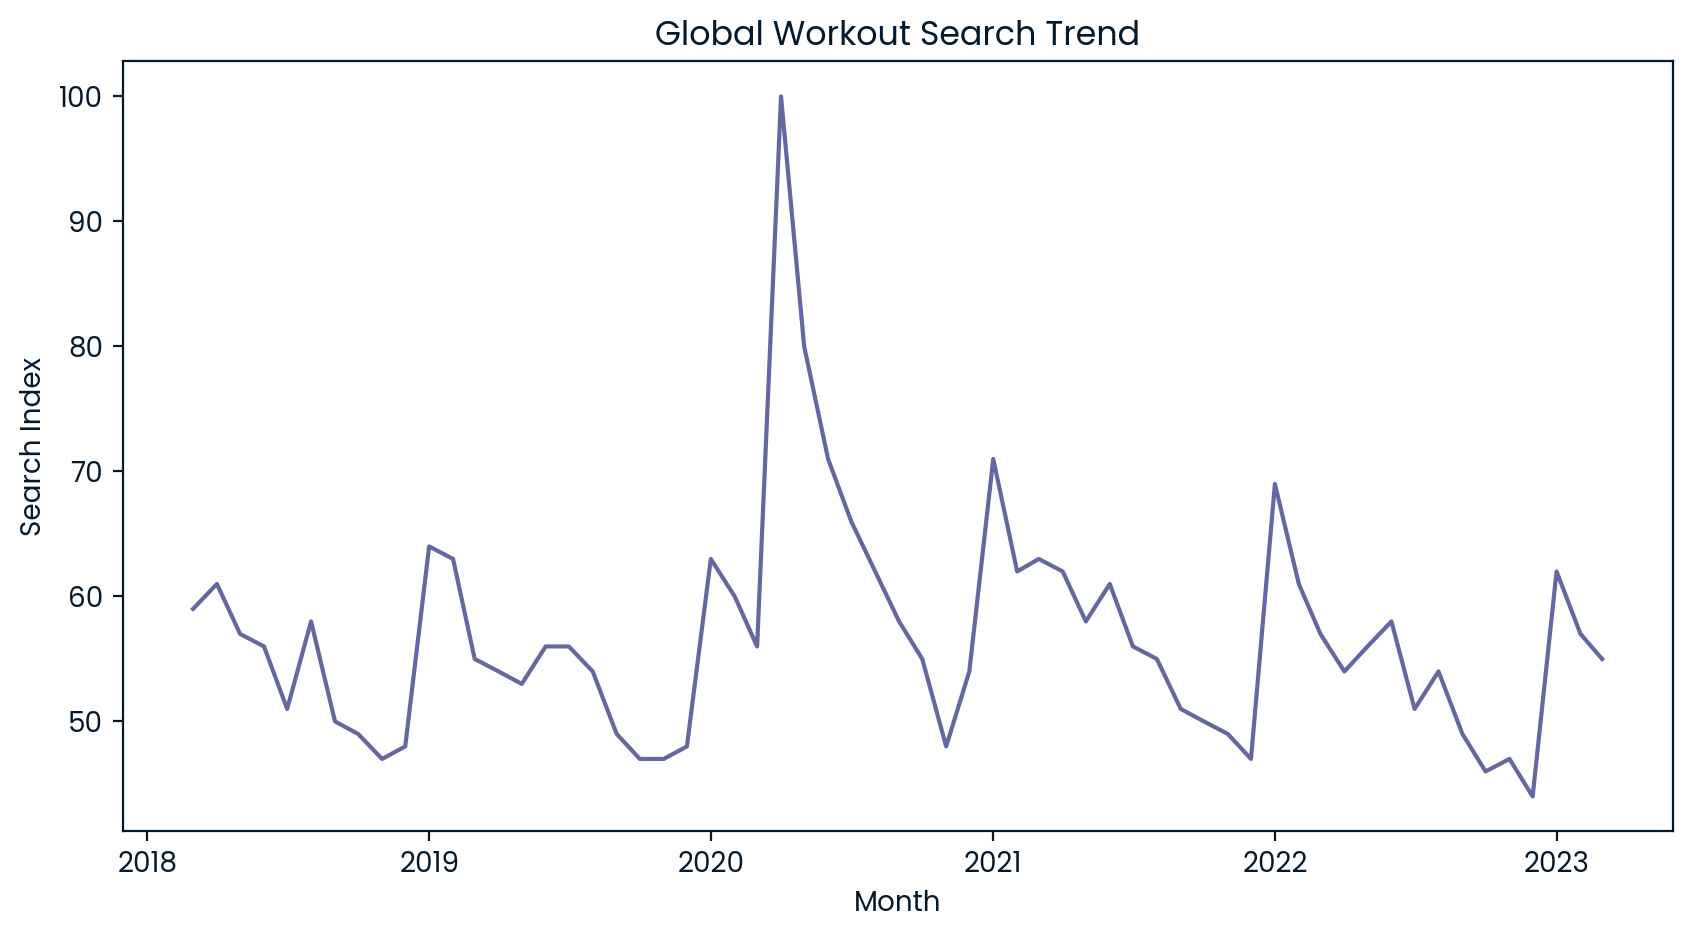

In [40]:
# Plot trend
plt.figure(figsize=(10,5))
plt.plot(workout["month"], workout["workout_worldwide"])
plt.title("Global Workout Search Trend")
plt.xlabel("Month")
plt.ylabel("Search Index")
plt.show()

In [41]:
# Find peak
peak_row = workout.loc[workout["workout_worldwide"].idxmax()]
year_str = str(peak_row["month"].year)

print("Peak year:        ", year_str)

Peak year:         2020


## 3. Find the most popular keywords for the current year and during covid
Use the three_keywords.csv file and line plot to identify the most popular keywords.
- Adding multiple variables to a line plot.


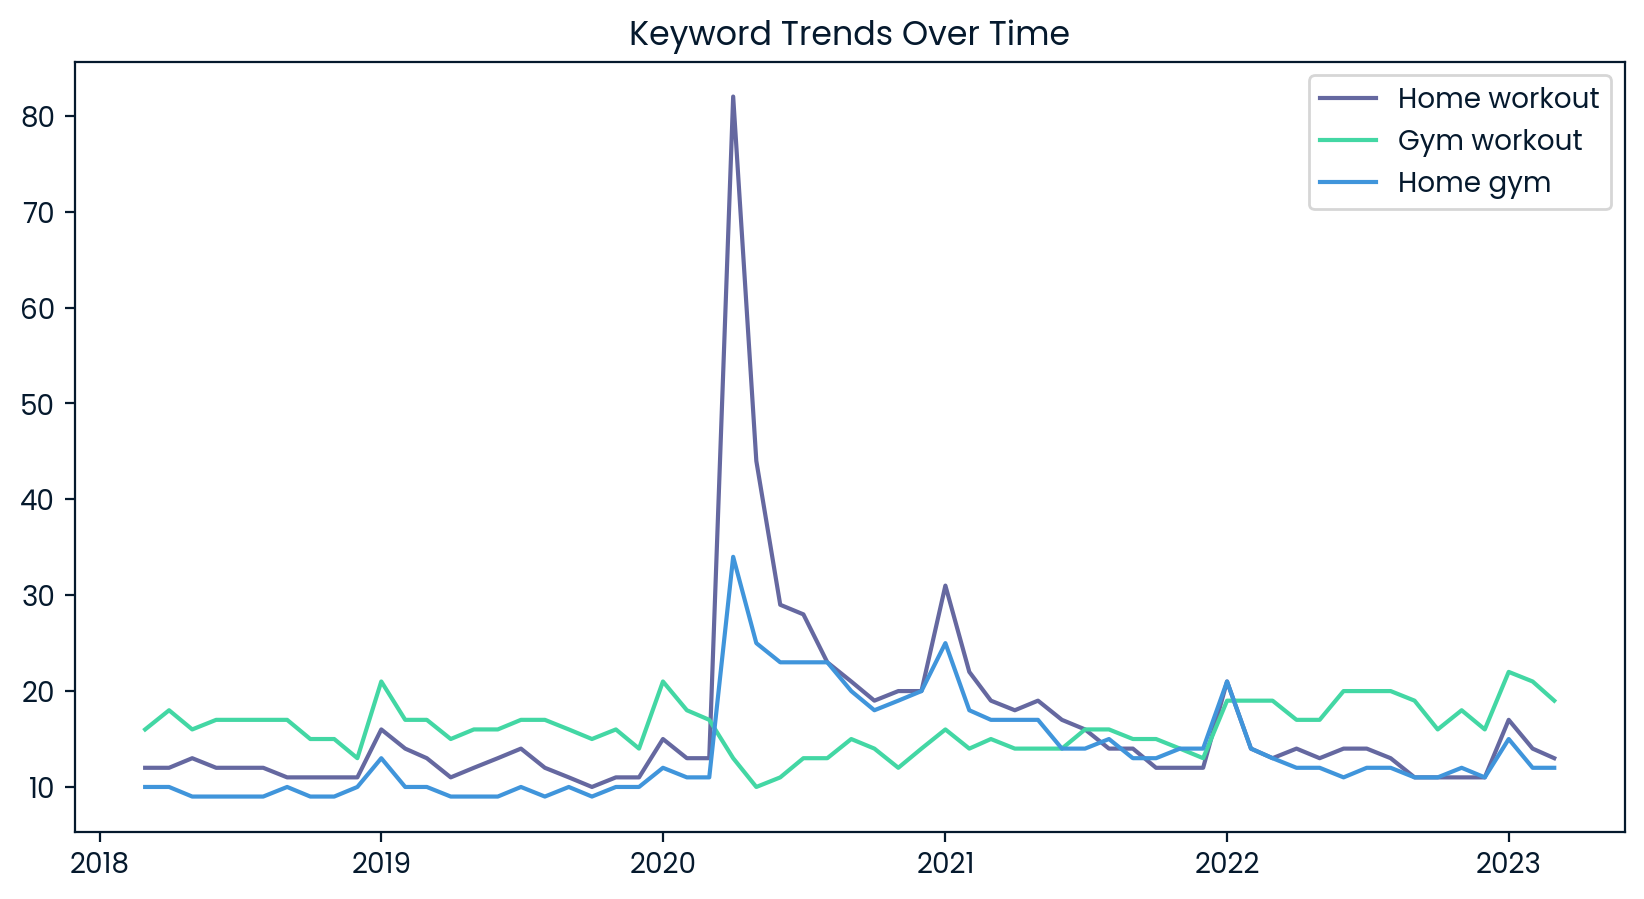

In [42]:
# Plot keywords
plt.figure(figsize=(10,5))
plt.plot(three_keywords["month"], three_keywords["home_workout_worldwide"], label="Home workout")
plt.plot(three_keywords["month"], three_keywords["gym_workout_worldwide"], label="Gym workout")
plt.plot(three_keywords["month"], three_keywords["home_gym_worldwide"], label="Home gym")
plt.legend()
plt.title("Keyword Trends Over Time")
plt.show()

In [43]:
# Filter COVID period (approx. 2020)
covid_data = three_keywords[three_keywords["month"].dt.year == 2020]

# Average values during COVID
covid_avg = covid_data[
    ["home_workout_worldwide", "gym_workout_worldwide", "home_gym_worldwide"]
].mean()

peak_covid = covid_avg.idxmax().replace("_worldwide", "")

In [44]:
# Most recent data 
latest = three_keywords.iloc[-1][["home_workout_worldwide", "gym_workout_worldwide", "home_gym_worldwide"]]

# Convert to numeric (safe conversion)
latest = pd.to_numeric(latest, errors='coerce')

# Now find max
current = latest.idxmax().replace("_worldwide", "")

print("Peak during COVID:       ", peak_covid)
print("Current most popular:    ", current)

Peak during COVID:        home_workout
Current most popular:     gym_workout


## 4. Find the country with the highest interest for workouts
To find the country with the highest interest in workouts, use the results by country and inspect the countries' interest values.
- Identify the workout data saved by country
- Identify the countries within the DataFrame


In [45]:
# Filter specific countries
countries = ["United States", "Australia", "Japan"]
filtered = workout_geo[workout_geo["country"].isin(countries)]

# Find highest
top_country = filtered.loc[
    filtered["workout_2018_2023"].idxmax(), "country"
]

print("Top country:        ", top_country)

Top country:         United States


## 5. Find the country in the MESA region with the highest interest in home workouts
Using a filter, limit your dataset to the list of MESA countries, then sort the data on the home workouts column to identify the one with the highest interest

In [46]:
# Filter countries
target_countries = ["Philippines", "Malaysia"]
home_filtered = three_keywords_geo[three_keywords_geo["Country"].isin(target_countries)]

# Find highest
home_workout_geo = home_filtered.loc[home_filtered["home_workout_2018_2023"].idxmax(), "Country"]

print("Best market for home workouts:        ", home_workout_geo)

Best market for home workouts:         Philippines


---


In [47]:
print("Task 1: Find the time of peak searches for workout")
print("        Peak year:        ", year_str)

print("Task 2: Find the most popular keywords during covid")
print("        Peak during COVID:        ", peak_covid)

print("Task 3: Find the most popular keywords for the current year")
print("        Current most popular:        ", current)

print("Task 4: Find the country with the highest interest for workouts")
print("        Top country:        ", top_country)

print("Task 5: Find the country with the highest interest in home workouts")
print("        Best market for home workouts:        ", home_workout_geo)

Task 1: Find the time of peak searches for workout
        Peak year:         2020
Task 2: Find the most popular keywords during covid
        Peak during COVID:         home_workout
Task 3: Find the most popular keywords for the current year
        Current most popular:         gym_workout
Task 4: Find the country with the highest interest for workouts
        Top country:         United States
Task 5: Find the country with the highest interest in home workouts
        Best market for home workouts:         Philippines
